# Librerias

In [1]:
#gestion de datos
import pandas as pd
import numpy as np

#algoritmos, entrenamiento y evaluacion del modelo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

#visualizacion de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Cargue de datos

In [2]:
data = pd.read_csv("heart.csv")

In [3]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
data.shape

(303, 14)

In [5]:
data.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


# 1. Gestion de datos

In [7]:
data = data[data['ca'] < 4] #drop the wrong ca values
data = data[data['thal'] > 0] # drop the wrong thal value
print(f'El tamaño de los datos ahora es {len(data)} antes era 303!')
print(len(data))

El tamaño de los datos ahora es 296 antes era 303!
296


## renombrar las columnas dentro del archivo

In [8]:
data = data.rename(
    columns = {'cp':'chest_pain_type',
               'trestbps':'resting_blood_pressure',
               'chol': 'cholesterol',
               'fbs': 'fasting_blood_sugar',
               'restecg' : 'resting_electrocardiogram',
               'thalach': 'max_heart_rate_achieved',
               'exang': 'exercise_induced_angina',
               'oldpeak': 'st_depression',
               'slope': 'st_slope',
               'ca':'num_major_vessels',
               'thal': 'thalassemia'},
    errors="raise")

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296 entries, 0 to 302
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        296 non-null    int64  
 1   sex                        296 non-null    int64  
 2   chest_pain_type            296 non-null    int64  
 3   resting_blood_pressure     296 non-null    int64  
 4   cholesterol                296 non-null    int64  
 5   fasting_blood_sugar        296 non-null    int64  
 6   resting_electrocardiogram  296 non-null    int64  
 7   max_heart_rate_achieved    296 non-null    int64  
 8   exercise_induced_angina    296 non-null    int64  
 9   st_depression              296 non-null    float64
 10  st_slope                   296 non-null    int64  
 11  num_major_vessels          296 non-null    int64  
 12  thalassemia                296 non-null    int64  
 13  target                     296 non-null    int64  
dtyp

## conversion de datos numericos a categoricos

In [10]:
data['sex'][data['sex'] == 0] = 'female'
data['sex'][data['sex'] == 1] = 'male'

data['chest_pain_type'][data['chest_pain_type'] == 0] = 'typical angina'
data['chest_pain_type'][data['chest_pain_type'] == 1] = 'atypical angina'
data['chest_pain_type'][data['chest_pain_type'] == 2] = 'non-anginal pain'
data['chest_pain_type'][data['chest_pain_type'] == 3] = 'asymptomatic'

data['fasting_blood_sugar'][data['fasting_blood_sugar'] == 0] = 'lower than 120mg/ml'
data['fasting_blood_sugar'][data['fasting_blood_sugar'] == 1] = 'greater than 120mg/ml'

data['resting_electrocardiogram'][data['resting_electrocardiogram'] == 0] = 'normal'
data['resting_electrocardiogram'][data['resting_electrocardiogram'] == 1] = 'ST-T wave abnormality'
data['resting_electrocardiogram'][data['resting_electrocardiogram'] == 2] = 'left ventricular hypertrophy'

data['exercise_induced_angina'][data['exercise_induced_angina'] == 0] = 'no'
data['exercise_induced_angina'][data['exercise_induced_angina'] == 1] = 'yes'

data['st_slope'][data['st_slope'] == 0] = 'upsloping'
data['st_slope'][data['st_slope'] == 1] = 'flat'
data['st_slope'][data['st_slope'] == 2] = 'downsloping'

data['thalassemia'][data['thalassemia'] == 1] = 'fixed defect'
data['thalassemia'][data['thalassemia'] == 2] = 'normal'
data['thalassemia'][data['thalassemia'] == 3] = 'reversable defect'

C:\Users\juanp\AppData\Local\Temp\ipykernel_1756\2966579873.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['sex'][data['sex'] == 0] = 'female'
C:\Users\juanp\AppData\Local\Temp\ipykernel_1756\2966579873.py:1: SettingWithCopyWarning

In [11]:
data.head() 

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_electrocardiogram,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,male,asymptomatic,145,233,greater than 120mg/ml,normal,150,no,2.3,upsloping,0,fixed defect,1
1,37,male,non-anginal pain,130,250,lower than 120mg/ml,ST-T wave abnormality,187,no,3.5,upsloping,0,normal,1
2,41,female,atypical angina,130,204,lower than 120mg/ml,normal,172,no,1.4,downsloping,0,normal,1
3,56,male,atypical angina,120,236,lower than 120mg/ml,ST-T wave abnormality,178,no,0.8,downsloping,0,normal,1
4,57,female,typical angina,120,354,lower than 120mg/ml,ST-T wave abnormality,163,yes,0.6,downsloping,0,normal,1


In [12]:
data.dtypes

age                            int64
sex                           object
chest_pain_type               object
resting_blood_pressure         int64
cholesterol                    int64
fasting_blood_sugar           object
resting_electrocardiogram     object
max_heart_rate_achieved        int64
exercise_induced_angina       object
st_depression                float64
st_slope                      object
num_major_vessels              int64
thalassemia                   object
target                         int64
dtype: object

In [13]:
# numerical fearures 6
num_feats = ['age', 'cholesterol', 'resting_blood_pressure', 'max_heart_rate_achieved', 'st_depression', 'num_major_vessels']
# categorical (binary)
bin_feats = ['sex', 'fasting_blood_sugar', 'exercise_induced_angina', 'target']
# caterorical (multi-)
nom_feats= ['chest_pain_type', 'resting_electrocardiogram', 'st_slope', 'thalassemia']
cat_feats = nom_feats + bin_feats

## Estadistica descriptiva de las variables numericas

### Aplicar un analisis descriptivo de las variables

Ejemplo del codigo:
```python
data[num_feats].describe().T
```

In [14]:
data[num_feats].describe().T

,count,mean,std,min,25%,50%,75%,max
age,296.0,54.523649,9.059471,29.0,48.0,56.0,61.00,77.0
cholesterol,296.0,247.155405,51.977011,126.0,211.0,242.5,275.25,564.0
resting_blood_pressure,296.0,131.604730,17.726620,94.0,120.0,130.0,140.00,200.0
max_heart_rate_achieved,296.0,149.560811,22.970792,71.0,133.0,152.5,166.00,202.0
st_depression,296.0,1.059122,1.166474,0.0,0.0,0.8,1.65,6.2
num_major_vessels,296.0,0.679054,0.939726,0.0,0.0,0.0,1.00,3.0


### Resumen estadístico variables numericas
* **Edad:**
    * La edad promedio en el conjunto de datos es de 54.5 años.
    * La edad máxima registrada es de 77 años, mientras que la mínima es de 29 años.
* **Colesterol:**
    * El nivel promedio de colesterol registrado es de 247.15 mg/dl (miligramos por decilitro).
    * El nivel máximo es de 564 mg/dl y el mínimo es de 126 mg/dl.
    * *Nota:* Según la literatura médica, un nivel saludable de colesterol es < 200 mg/dl; niveles elevados suelen estar asociados con enfermedades cardíacas.
* **Presión Arterial en Reposo:**
    * Media: 131 mmHg (milimetros de mercurio) | Máxima: 200 mmHg | Mínima: 94 mmHg.
* **Frecuencia Cardíaca Máxima Alcanzada:**
    * El promedio registrado es de 149.5 lpm (latidos por minuto).
    * El valor máximo es de 202 lpm y el mínimo es de 71 lpm.
* **Depresión del Segmento ST (St_depression):**
    * El valor promedio es de 1.06. El máximo es de 6.2 y el mínimo es 0.
* **Número de Vasos Sanguíneos Principales:**
    * Se observa un máximo de 3 vasos y un mínimo de 0.
    * El valor medio es de 0.68.

## Analisis de la distribución de la variable objetivo

Usar el siguiente codigo:

```python
ax = sns.countplot(x = 'target', data = data)
ax.bar_label(ax.containers[0])
plt.show()
```

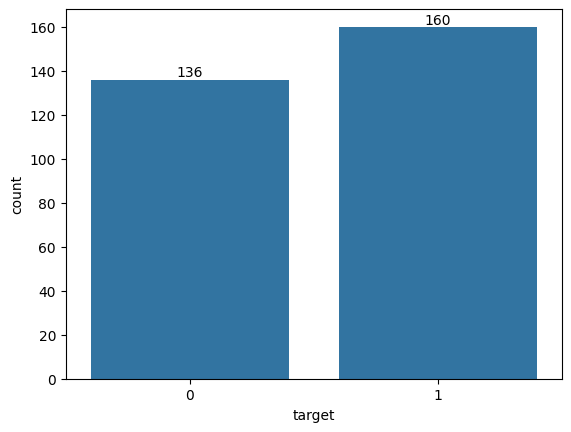

In [15]:
ax = sns.countplot(x='target', data=data)
ax.bar_label(ax.containers[0])
plt.show()

## Analisis de las variables categoricas

* **Sexo:**
    * La muestra cuenta con una mayor cantidad de pacientes hombres.
    * Sin embargo, las mujeres parecen sufrir de condiciones cardíacas en mayor proporción que los hombres en este conjunto de datos.

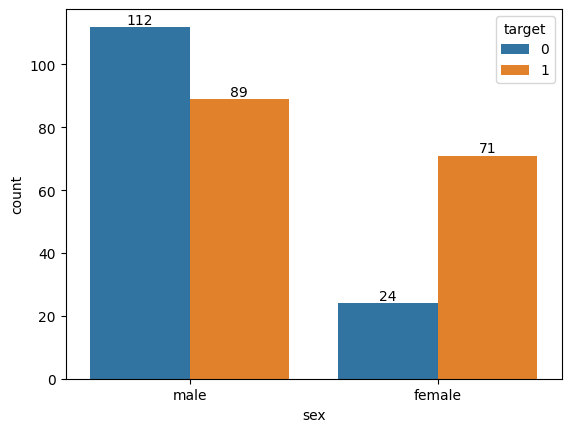

In [16]:
ax = sns.countplot(x = 'sex', data = data, hue = 'target')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

### Análisis de Variables Clínicas

* **Dolor en el Pecho (Chest Pain):**    
    * Los pacientes que presentaron angina atípica o dolor no anginoso tienen mayor probabilidad de padecer una enfermedad cardíaca.

Usar el siguiente codigo ejemplo:

```python
ax = sns.countplot(x = 'chest_pain_type', data = data, hue = 'target')
for container in ax.containers:
    ax.bar_label(container)
plt.show()
```

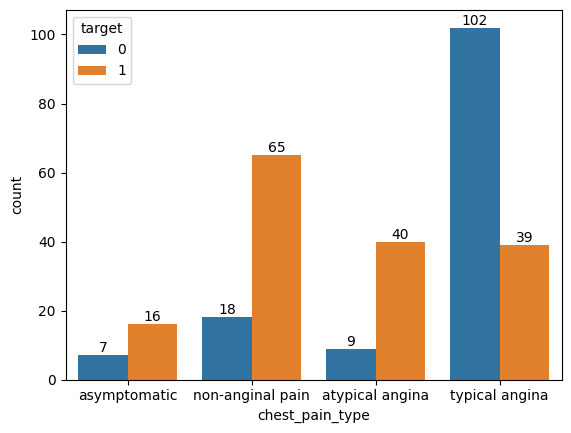

In [17]:
ax = sns.countplot(x = 'chest_pain_type', data = data, hue = 'target')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

* **Electrocardiograma en Reposo:**
    * Los pacientes con hipertrofia ventricular izquierda son la minoría (~1.4%). El resto se divide casi equitativamente entre aquellos con anomalías del segmento ST-T y pruebas normales.
    * Las anomalías del ST-T parecen tener una mejor correlación con la variable objetivo; la mayoría de los pacientes con este resultado terminaron con una enfermedad cardíaca.

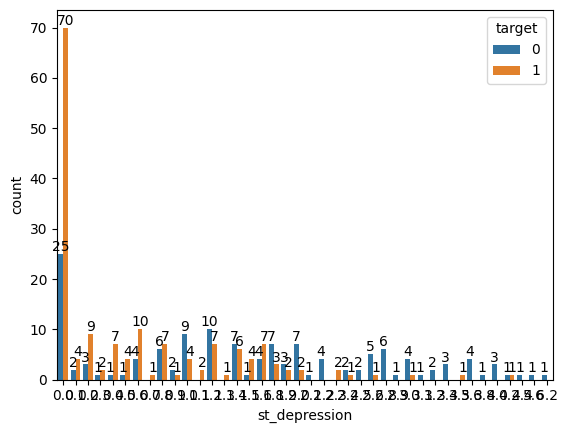

In [18]:
ax = sns.countplot(x = 'st_depression', data = data, hue = 'target')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

* **Pendiente del Segmento ST (ST-Slope):**
    * La mayoría de los pacientes presentan una pendiente descendente o plana.
    * Las pendientes descendentes son un fuerte indicio de que el paciente podría tener una enfermedad cardíaca.

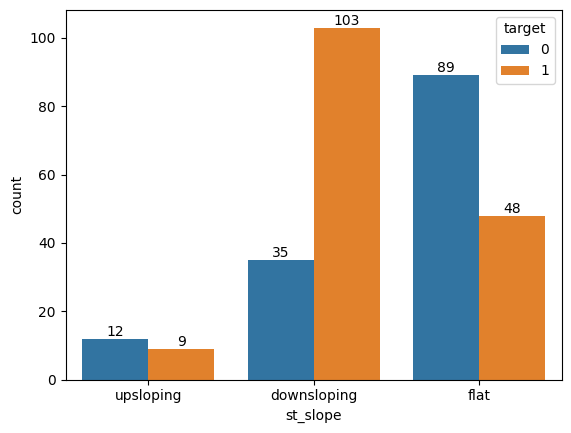

In [19]:
ax = sns.countplot(x = 'st_slope', data = data, hue = 'target')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

* **Talasemia:**
    * La mayoría de los pacientes tienen un resultado normal o un defecto reversible.
    * Curiosamente, los pacientes con defectos de talasemia (reversibles + fijos) tienen menos probabilidades de tener una enfermedad cardíaca, mientras que aquellos con talasemia normal tienen más probabilidades. Este resultado parece no ser intuitivo.

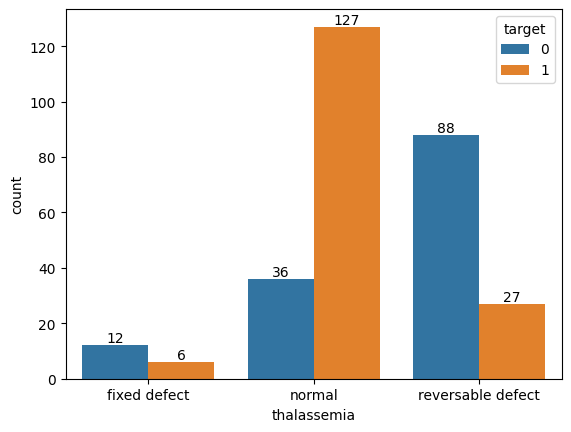

In [20]:
ax = sns.countplot(x = 'thalassemia', data = data, hue = 'target')
for container in ax.containers:
    ax.bar_label(container)
plt.show()  

* **Glucemia en Ayunas (Fasting Blood Sugar):**
    * Los pacientes con niveles bajos de azúcar en sangre (menos de 120 mg/dl) son la mayoría, representando aproximadamente el 85% de la muestra.

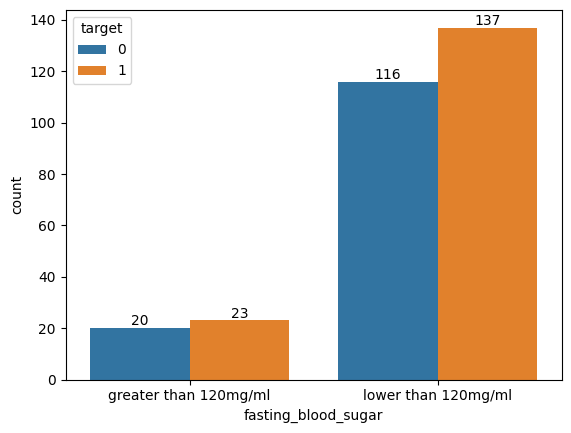

In [21]:
ax = sns.countplot(x = 'fasting_blood_sugar', data = data, hue = 'target')
for container in ax.containers:
    ax.bar_label(container)
plt.show()  

* **Angina Inducida por el Ejercicio:**
    * Dos tercios de los pacientes no mostraron angina inducida por el ejercicio.
    * El 76% de los pacientes con angina inducida por ejercicio no tenían afecciones cardíacas. En contraste, el ~69% de quienes no la experimentaron fueron diagnosticados con una condición cardíaca.

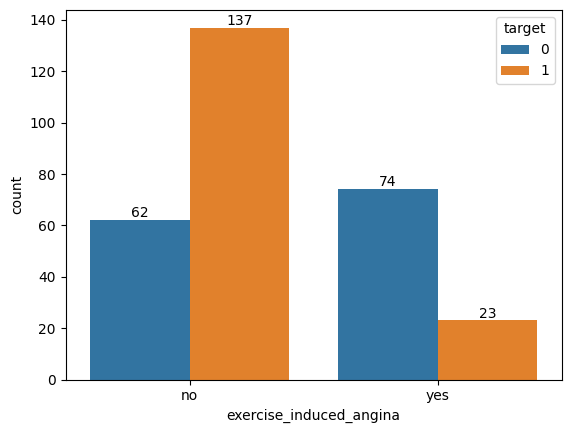

In [22]:
#Inserte codigo
ax = sns.countplot(x = 'exercise_induced_angina', data = data, hue = 'target')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

### Analisis de histogramas

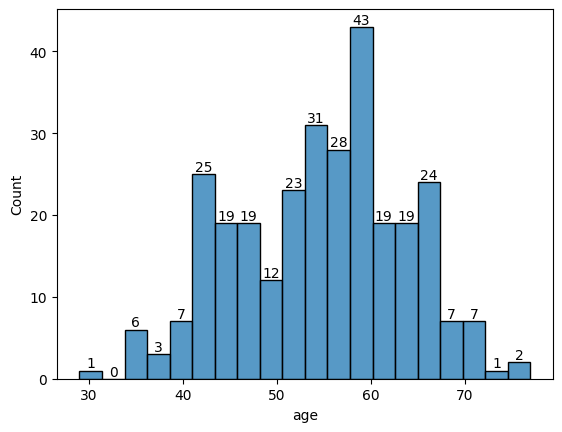

In [23]:
#ax = sns.histplot(data = data, x = 'age', hue = 'target', multiple = 'stack', bins = 20)
ax = sns.histplot(data = data, x = 'age', bins = 20)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

##**3.5 Conclusiones gestión de datos**

* **¿Cuantos pacientes hay?**
  * 296
* **¿Hay valores perdidos?**
  * No hay valores perdidos.
* **¿Cuantas variables numericas y categoricas existen?**
  * 6 numericas y 7 categoricas
* **¿La variable objetivo esta balanceada?**
  * Si
* **¿Cuales son las variables que mejor pueden predecir la enfermedad cardiaca?**

## 1.1 Division de la base de datos

### Dividir el dataset usando solo las variables numericas

Ejemplo del codigo:
```python
seed = 0
test_size = None

features = None

X = data[features]
y = data['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = test_size, random_state=seed)
print("el tamaño de los datos de entrenamiento es: ", len(X_train))
```

In [24]:
#insertar codigo
seed = 0
test_size = 0.3

features = num_feats

X = data[features]
y = data['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = test_size, random_state=seed)
print("el tamaño de los datos de entrenamiento es: ", len(X_train))

el tamaño de los datos de entrenamiento es:  207


### 4.1 Principios de la función
La función de la regresión logística utiliza la función sigmoide para mapear los resultados a un rango entre 0 y 1:

$$h_\theta(x) = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$$

Donde:
* $w^T x + b$ es la combinación lineal de las entradas y los parámetros (pesos y sesgo).
* $\sigma$ representa la función logística o sigmoide.
* $e$ es la constante de Euler o simplemente el numero $e$ (aprox. 2.718).

#### 4.1.1 Interpretación de la función

Al usar la estructura de la función sigmoide, el modelo asegura que la salida sea una probabilidad.

* Si el valor de $z$ es muy grande y positivo, $e^{-z}$ tiende a 0, por lo que $h(x)$ se acerca a 1.
* Si el valor de $z$ es muy grande y negativo, $e^{-z}$ tiende a infinito, por lo que $h(x)$ se acerca a 0.

El valor de $z$ es la computación de las variables del modelo:

$$h_\theta(x) = \frac{1}{1 + e^{-z}}$$
donde $z = w_1x_1 + w_2x_2 + ... + w_nx_n + b$

![función sigmoide](https://upload.wikimedia.org/wikipedia/commons/thumb/6/66/Funci%C3%B3n_sigmoide_01.svg/1280px-Funci%C3%B3n_sigmoide_01.svg.png)

# 2. Aprendizaje del modelo

### 2.1 Función de Pérdida: Entropía Cruzada Binaria (Log Loss)

En la regresión logística, no usamos el Error Cuadrático Medio porque la función sigmoide generaría una superficie no convexa (con muchos "valles" falsos). En su lugar, usamos la Log Loss, que mide la diferencia entre la probabilidad predicha $h_\theta(x)$ y el valor real $y \in \{0, 1\}$.
Para un solo ejemplo de entrenamiento, la pérdida se define como:

$$Loss(h_\theta(x), y) = \begin{cases} -\log(h_\theta(x)) & \text{si } y = 1 \\ -\log(1 - h_\theta(x)) & \text{si } y = 0 \end{cases}$$

#### 2.1.1 Fórmula General (Función de Costo $J(\theta)$)

Para optimizar el modelo sobre todo el conjunto de datos ($m$ ejemplos), combinamos ambas condiciones en una sola ecuación:

$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)}))]$$

**¿Por qué funciona esta lógica?**

* Si el valor real es $y=1$: Cuando el modelo predice algo cercano a 1, el $-\log(1)$ es casi 0 (poca pérdida). Pero si el modelo predice algo cercano a 0, el $-\log$ crece hacia el infinito, penalizando fuertemente el error.
* Si el valor real es $y=0$: El segundo término de la ecuación se activa. Si el modelo predice algo cercano a 1, la pérdida será altísima para obligar a los pesos a ajustarse.

In [25]:
#Esta linea selecciona el modelo
clf = LogisticRegression(solver="liblinear", random_state=seed)
#clf = LogisticRegression()
#Esta linea ajusta el modelo con los datos de entrenamiento
clf.fit(X_train, y_train)

LogisticRegression(random_state=0, solver='liblinear')

# 3 Evaluación

## 3.1 Evaluación del Modelo: Matriz de Confusión y Métricas

La matriz de confusión es una herramienta que permite visualizar el desempeño de un algoritmo de clasificación. Compara las predicciones del modelo con los valores reales del conjunto de datos.

#### Estructura de la Matriz
Se compone de cuatro cuadrantes fundamentales:

* Verdaderos Positivos (TP): Predicción positiva, valor real positivo.
* Verdaderos Negativos (TN): Predicción negativa, valor real negativo.
* Falsos Positivos (FP): Predicción positiva, valor real negativo (Error Tipo I).
* Falsos Negativos (FN): Predicción negativa, valor real positivo (Error Tipo II).


## 3.2 Métricas Derivadas

A partir de estos valores, calculamos métricas que nos permiten entender el comportamiento del modelo según el problema de negocio o investigación:

#### 1. Exactitud (Accuracy)
Mide el porcentaje total de aciertos sobre el total de casos.
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

#### 2. Precisión (Precision)
Responde a la pregunta: *De todos los que el modelo predijo como positivos, ¿cuántos lo eran realmente?* Es clave para evitar Falsos Positivos.
$$Precision = \frac{TP}{TP + FP}$$

#### 3. Sensibilidad o Exhaustividad (Recall / Sensitivity)
Responde a la pregunta: *De todos los casos que son positivos en la realidad, ¿cuántos logró encontrar el modelo?* Es vital para evitar Falsos Negativos.
$$Recall = \frac{TP}{TP + FN}$$

#### 4. Puntuación F1 (F1-Score)
Es el promedio armónico entre la Precisión y el Recall. Se utiliza cuando las clases están desbalanceadas.
$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

---

In [26]:
pred_train = clf.predict(X_train)
accuracy_train = accuracy_score(y_train, pred_train)
#print(accuracy_train)

cols=["metricas de desempeño", "Accuracy", "Recall", "Precision", "F1"]
data_table = pd.DataFrame(columns=cols)
pred_proba = clf.predict_proba(X_train)[:, 1]

# confusion matric, cm
cm = confusion_matrix(y_train, pred_train)

# recall: TP/(TP+FN)
recall = cm[1,1]/(cm[1,1] +cm[1,0])

# precision: TP/(TP+FP)
precision = cm[1,1]/(cm[1,1] +cm[0,1])

# F1 score: TP/(TP+FP)
f1 = 2*recall*precision/(recall + precision)

df = pd.DataFrame([["Re_logistica_train", accuracy_train*100, recall, precision, f1]], columns=cols)
data_table = pd.concat([data_table, df], ignore_index=True)

np.round(data_table.reset_index(drop=True), 2)

C:\Users\juanp\AppData\Local\Temp\ipykernel_1756\3315291997.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_table = pd.concat([data_table, df], ignore_index=True)


,metricas de desempeño,Accuracy,Recall,Precision,F1
0,Re_logistica_train,79.71,0.88,0.78,0.83


In [27]:
pred = clf.predict(X_val)
accuracy = accuracy_score(y_val, pred)
#print(accuracy)

pred_proba = clf.predict_proba(X_val)[:, 1]

# confusion matric, cm
cm = confusion_matrix(y_val, pred)

# recall: TP/(TP+FN)
recall = cm[1,1]/(cm[1,1] +cm[1,0])

# precision: TP/(TP+FP)
precision = cm[1,1]/(cm[1,1] +cm[0,1])

# F1 score: TP/(TP+FP)
f1 = 2*recall*precision/(recall + precision)

df = pd.DataFrame([["Re_logistica_val", accuracy*100, recall, precision, f1]], columns=cols)
data_table = pd.concat([data_table, df], ignore_index=True)

np.round(data_table.reset_index(drop=True), 2)

,metricas de desempeño,Accuracy,Recall,Precision,F1
0,Re_logistica_train,79.71,0.88,0.78,0.83
1,Re_logistica_val,76.40,0.91,0.70,0.79


# Codificación de las variables o encoding

In [28]:
from sklearn.preprocessing import OneHotEncoder

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296 entries, 0 to 302
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        296 non-null    int64  
 1   sex                        296 non-null    object 
 2   chest_pain_type            296 non-null    object 
 3   resting_blood_pressure     296 non-null    int64  
 4   cholesterol                296 non-null    int64  
 5   fasting_blood_sugar        296 non-null    object 
 6   resting_electrocardiogram  296 non-null    object 
 7   max_heart_rate_achieved    296 non-null    int64  
 8   exercise_induced_angina    296 non-null    object 
 9   st_depression              296 non-null    float64
 10  st_slope                   296 non-null    object 
 11  num_major_vessels          296 non-null    int64  
 12  thalassemia                296 non-null    object 
 13  target                     296 non-null    int64  
dtyp

## ¿Qué es el One-Hot Encoding?

El **One-Hot Encoding** (Codificación One-Hot) es una técnica fundamental de preprocesamiento de datos en Machine Learning. Su propósito principal es convertir variables categóricas (texto) en variables numéricas (binarias) para que los algoritmos matemáticos puedan procesarlas adecuadamente.

## ¿Cómo funciona?
El proceso toma una columna que contiene distintas categorías y crea **una nueva columna para cada categoría única**. Posteriormente, rellena estas nuevas columnas con un `1` (verdadero) si la categoría original estaba presente en esa fila, y con un `0` (falso) si no lo estaba.

### Ejemplo visual
Imagina que tienes una columna llamada "Color" con los valores *Rojo, Verde y Azul*. Tras aplicar One-Hot Encoding, la transformación se vería así:

| Color Original | Color_Rojo | Color_Verde | Color_Azul |
| :--- | :---: | :---: | :---: |
| **Rojo** | 1 | 0 | 0 |
| **Verde** | 0 | 1 | 0 |
| **Azul** | 0 | 0 | 1 |
| **Rojo** | 1 | 0 | 0 |

## ¿Por qué es estrictamente necesario?
Esta técnica se utiliza principalmente para **evitar que el modelo asuma un falso orden jerárquico o valor matemático** entre las categorías.

Si, por ejemplo, simplemente reemplazáramos los textos por números secuenciales (`Rojo = 1`, `Verde = 2`, `Azul = 3`), el algoritmo de Machine Learning (como una Regresión Lineal o una Red Neuronal) pensaría erróneamente que:
* El "Azul" (3) vale más o es "mayor" que el "Rojo" (1).
* El promedio matemático entre "Rojo" (1) y "Azul" (3) da como resultado "Verde" (2).

Al utilizar un enfoque binario de `0` y `1`, **todas las categorías quedan exactamente al mismo nivel (distancia equidistante)**, eliminando cualquier relación de jerarquía inexistente y permitiendo que el modelo extraiga conclusiones precisas y lógicas de los datos.

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296 entries, 0 to 302
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        296 non-null    int64  
 1   sex                        296 non-null    object 
 2   chest_pain_type            296 non-null    object 
 3   resting_blood_pressure     296 non-null    int64  
 4   cholesterol                296 non-null    int64  
 5   fasting_blood_sugar        296 non-null    object 
 6   resting_electrocardiogram  296 non-null    object 
 7   max_heart_rate_achieved    296 non-null    int64  
 8   exercise_induced_angina    296 non-null    object 
 9   st_depression              296 non-null    float64
 10  st_slope                   296 non-null    object 
 11  num_major_vessels          296 non-null    int64  
 12  thalassemia                296 non-null    object 
 13  target                     296 non-null    int64  
dtyp

In [31]:
print(f'Categorical features: {cat_feats}')
print(f'Categorical features: {nom_feats}')

Categorical features: ['chest_pain_type', 'resting_electrocardiogram', 'st_slope', 'thalassemia', 'sex', 'fasting_blood_sugar', 'exercise_induced_angina', 'target']
Categorical features: ['chest_pain_type', 'resting_electrocardiogram', 'st_slope', 'thalassemia']


In [32]:
def aplicar_one_hot_encoding(df, columnas_categoricas, drop_first=False):    
    # 1. Crear una copia para no modificar el DataFrame original por accidente
    df_resultado = df.copy()
    
    # 2. Configurar el codificador
    # handle_unknown='ignore' evita errores si en el futuro aparecen categorías nuevas
    drop_param = 'first' if drop_first else None
    encoder = OneHotEncoder(sparse_output=False, drop=drop_param, handle_unknown='ignore')
    
    # 3. Entrenar y transformar solo las columnas indicadas
    datos_codificados = encoder.fit_transform(df_resultado[columnas_categoricas])
    
    # 4. Obtener los nombres de las nuevas columnas generadas
    nuevos_nombres = encoder.get_feature_names_out(columnas_categoricas)
    
    # 5. Crear un DataFrame temporal con los datos codificados
    # Mantenemos el índice original para no desalinear las filas al concatenar
    df_temp = pd.DataFrame(datos_codificados, columns=nuevos_nombres, index=df_resultado.index)
    
    # 6. Eliminar las columnas originales de texto y añadir las nuevas columnas numéricas
    df_resultado = df_resultado.drop(columns=columnas_categoricas)
    df_final = pd.concat([df_resultado, df_temp], axis=1)
    
    return df_final

## Datos Transformados

In [ ]:
data_transformado = aplicar_one_hot_encoding(data, nom_feats)
#Linea para guardar los datos transformados en un archivo CSV
data_transformado.to_csv("data_transformado.csv", index=False)
print(data_transformado.info())


<class 'pandas.core.frame.DataFrame'>
Index: 296 entries, 0 to 302
Data columns (total 23 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   age                                                     296 non-null    int64  
 1   sex                                                     296 non-null    object 
 2   resting_blood_pressure                                  296 non-null    int64  
 3   cholesterol                                             296 non-null    int64  
 4   fasting_blood_sugar                                     296 non-null    object 
 5   max_heart_rate_achieved                                 296 non-null    int64  
 6   exercise_induced_angina                                 296 non-null    object 
 7   st_depression                                           296 non-null    float64
 8   num_major_vessels                            

# Modelo Xgboost

In [34]:
from xgboost import XGBClassifier

## ¿Qué es XGBoost?

**XGBoost** (*eXtreme Gradient Boosting*) es uno de los algoritmos de Machine Learning más potentes y ganadores de competiciones en el mundo de la ciencia de datos. Pertenece a la familia de los métodos de ensamble (*ensemble learning*), lo que significa que no confía en un solo modelo grande, sino que combina cientos de modelos pequeños y simples (generalmente árboles de decisión) para lograr una predicción final extremadamente precisa.

## ¿Cómo funciona la "Potenciación del Gradiente"?

La verdadera inteligencia de XGBoost radica en la técnica de *Gradient Boosting*. A diferencia de otros algoritmos como Random Forest (que construye muchos árboles al mismo tiempo de forma independiente), XGBoost construye sus árboles de manera secuencial y autocorrectiva:

* **Paso 1:** Construye un primer árbol base para hacer predicciones iniciales.
* **Paso 2:** Evalúa exactamente en qué filas de tus datos se equivocó este primer árbol (calcula los residuos o errores).
* **Paso 3:** Construye un segundo árbol cuyo único objetivo matemático es predecir y corregir los errores del primero.
* **Paso 4:** El proceso se repite. El tercer árbol corrige al segundo, el cuarto al tercero, y así sucesivamente.

Formalmente, la predicción final $\hat{y}_i$ para una observación $i$ es la suma de las funciones de predicción de los $K$ árboles generados:
$$ \hat{y}_i = \sum_{k=1}^{K} f_k(x_i) $$

In [35]:
seed = 48
features = data_transformado.drop(columns=['target']).columns
X = data_transformado[features]
y = data_transformado['target']

In [36]:
# 2. Tratar las columnas 'object' restantes
# Identificamos 'sex', 'fasting_blood_sugar' y 'exercise_induced_angina'
columnas_object = X.select_dtypes(include=['object']).columns

# Convertimos estas columnas al tipo 'category' para que XGBoost las maneje nativamente
for col in columnas_object:
    X[col] = X[col].astype('category')

# 3. Dividir los datos en entrenamiento (70%) y prueba (30%)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=seed, 
    stratify=y # Mantiene la proporción de clases (0 y 1) en train y test
)

# 4. Configurar e inicializar el modelo XGBoost
modelo_xgb = XGBClassifier(
    n_estimators=100,           # Cantidad de árboles
    learning_rate=0.1,          # Tasa de aprendizaje
    max_depth=5,                # Profundidad máxima de cada árbol
    enable_categorical=True,    # !IMPORTANTE: Activa el soporte para columnas 'category'
    tree_method='hist',         # !IMPORTANTE: Obligatorio usar 'hist' con datos categóricos
    random_state=seed,
    eval_metric='logloss',       # Métrica de evaluación para clasificación    
)

C:\Users\juanp\AppData\Local\Temp\ipykernel_1756\4122515498.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')
C:\Users\juanp\AppData\Local\Temp\ipykernel_1756\4122515498.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')
C:\Users\juanp\AppData\Local\Temp\ipykernel_1756\4122515498.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See

In [37]:
# 5. Entrenar el modelo
print("Entrenando el modelo...")
modelo_xgb.fit(X_train, y_train)
print("¡Entrenamiento completado!\n")

Entrenando el modelo...
¡Entrenamiento completado!



In [38]:
#Realizar predicciones con los datos de entrenamiento
pred_train = modelo_xgb.predict(X_train)
accuracy_train = accuracy_score(y_train, pred_train)
#print(accuracy)

pred_proba = modelo_xgb.predict_proba(X_train)[:, 1]

# confusion matric, cm
cm = confusion_matrix(y_train, pred_train)

# recall: TP/(TP+FN)
recall = cm[1,1]/(cm[1,1] +cm[1,0])

# precision: TP/(TP+FP)
precision = cm[1,1]/(cm[1,1] +cm[0,1])

# F1 score: TP/(TP+FP)
f1 = 2*recall*precision/(recall + precision)

df = pd.DataFrame([["Xgboost_train", accuracy_train*100, recall, precision, f1]], columns=cols)
data_table = pd.concat([data_table, df], ignore_index=True)

np.round(data_table.reset_index(drop=True), 2)

,metricas de desempeño,Accuracy,Recall,Precision,F1
0,Re_logistica_train,79.71,0.88,0.78,0.83
1,Re_logistica_val,76.40,0.91,0.70,0.79
2,Xgboost_train,100.00,1.00,1.00,1.00


In [39]:
# 6. Realizar predicciones con los datos de validación
pred = modelo_xgb.predict(X_val)
accuracy = accuracy_score(y_val, pred)
#print(accuracy)

pred_proba = modelo_xgb.predict_proba(X_val)[:, 1]

# confusion matric, cm
cm = confusion_matrix(y_val, pred)

# recall: TP/(TP+FN)
recall = cm[1,1]/(cm[1,1] +cm[1,0])

# precision: TP/(TP+FP)
precision = cm[1,1]/(cm[1,1] +cm[0,1])

# F1 score: TP/(TP+FP)
f1 = 2*recall*precision/(recall + precision)

df = pd.DataFrame([["Xgboost_val", accuracy*100, recall, precision, f1]], columns=cols)
data_table = pd.concat([data_table, df], ignore_index=True)

np.round(data_table.reset_index(drop=True), 2)

,metricas de desempeño,Accuracy,Recall,Precision,F1
0,Re_logistica_train,79.71,0.88,0.78,0.83
1,Re_logistica_val,76.40,0.91,0.70,0.79
2,Xgboost_train,100.00,1.00,1.00,1.00
3,Xgboost_val,83.15,0.85,0.84,0.85


# GridSearchCV

In [40]:
from sklearn.model_selection import GridSearchCV

In [41]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],   
}

xgb_base = XGBClassifier(
    enable_categorical=True,
    tree_method='hist',
    random_state=seed,
    eval_metric='logloss'
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

# Modelo final con los mejores hiperparámetros
mejor_modelo_xgb = grid_search.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores hiperparámetros encontrados:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}


In [42]:
pred_grid = mejor_modelo_xgb.predict(X_val)
accuracy = accuracy_score(y_val, pred_grid)
#print(accuracy)

pred_proba = mejor_modelo_xgb.predict_proba(X_val)[:, 1]

# confusion matric, cm
cm = confusion_matrix(y_val, pred_grid)

# recall: TP/(TP+FN)
recall = cm[1,1]/(cm[1,1] +cm[1,0])

# precision: TP/(TP+FP)
precision = cm[1,1]/(cm[1,1] +cm[0,1])

# F1 score: TP/(TP+FP)
f1 = 2*recall*precision/(recall + precision)

df = pd.DataFrame([["Xgboost_GridSearch", accuracy*100, recall, precision, f1]], columns=cols)
data_table = pd.concat([data_table, df], ignore_index=True)

np.round(data_table.reset_index(drop=True), 2)

,metricas de desempeño,Accuracy,Recall,Precision,F1
0,Re_logistica_train,79.71,0.88,0.78,0.83
1,Re_logistica_val,76.40,0.91,0.70,0.79
2,Xgboost_train,100.00,1.00,1.00,1.00
3,Xgboost_val,83.15,0.85,0.84,0.85
4,Xgboost_GridSearch,84.27,0.92,0.81,0.86


# Taller 2: Cargar una red neuronal, seleccionar los hiperparametros, entrenar el algoritmo y generar el modelo

In [43]:
from sklearn.neural_network import MLPClassifier

In [44]:
columnas_categoricas_nn = X.select_dtypes(include=["object", "category"]).columns
X_nn = pd.get_dummies(X, columns=columnas_categoricas_nn, dtype=float)

X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_nn, y,
    test_size=0.3,
    random_state=seed,
    stratify=y
)

red_neuronal = MLPClassifier(
    hidden_layer_sizes=(350,),
    random_state=seed,
    max_iter=300
)

red_neuronal.fit(X_train_nn, y_train_nn)

MLPClassifier(hidden_layer_sizes=(350,), max_iter=300, random_state=48)

In [45]:
pred_nn = red_neuronal.predict(X_train_nn)
accuracy = accuracy_score(y_train_nn, pred_nn)
#print(accuracy)

pred_proba = red_neuronal.predict_proba(X_train_nn)[:, 1]

# confusion matric, cm
cm = confusion_matrix(y_train_nn, pred_nn)

# recall: TP/(TP+FN)
recall = cm[1,1]/(cm[1,1] +cm[1,0])

# precision: TP/(TP+FP)
precision = cm[1,1]/(cm[1,1] +cm[0,1])

# F1 score: TP/(TP+FP)
f1 = 2*recall*precision/(recall + precision)

df = pd.DataFrame([["Red_Neuronal_train", accuracy*100, recall, precision, f1]], columns=cols)
data_table = pd.concat([data_table, df], ignore_index=True)

np.round(data_table.reset_index(drop=True), 2)

,metricas de desempeño,Accuracy,Recall,Precision,F1
0,Re_logistica_train,79.71,0.88,0.78,0.83
1,Re_logistica_val,76.40,0.91,0.70,0.79
2,Xgboost_train,100.00,1.00,1.00,1.00
3,Xgboost_val,83.15,0.85,0.84,0.85
4,Xgboost_GridSearch,84.27,0.92,0.81,0.86
5,Red_Neuronal_train,85.02,0.84,0.88,0.86


In [46]:
pred_nn = red_neuronal.predict(X_val_nn)
accuracy = accuracy_score(y_val_nn, pred_nn)
#print(accuracy)

#pred_proba = red_neuronal.predict_proba(X_val_nn)[:, 1]

# confusion matric, cm
cm = confusion_matrix(y_val_nn, pred_nn)

# recall: TP/(TP+FN)
recall = cm[1,1]/(cm[1,1] +cm[1,0])

# precision: TP/(TP+FP)
precision = cm[1,1]/(cm[1,1] +cm[0,1])

# F1 score: TP/(TP+FP)
f1 = 2*recall*precision/(recall + precision)

df = pd.DataFrame([["Red_Neuronal_val", accuracy*100, recall, precision, f1]], columns=cols)
data_table = pd.concat([data_table, df], ignore_index=True)

np.round(data_table.reset_index(drop=True), 2)

,metricas de desempeño,Accuracy,Recall,Precision,F1
0,Re_logistica_train,79.71,0.88,0.78,0.83
1,Re_logistica_val,76.40,0.91,0.70,0.79
2,Xgboost_train,100.00,1.00,1.00,1.00
3,Xgboost_val,83.15,0.85,0.84,0.85
4,Xgboost_GridSearch,84.27,0.92,0.81,0.86
5,Red_Neuronal_train,85.02,0.84,0.88,0.86
6,Red_Neuronal_val,83.15,0.77,0.90,0.83


# Interpretacion

In [47]:
import shap

c:\Users\juanp\taller_1_aiSalud\.env_ia\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


- Los SHAP values (SHapley Additive exPlanations) son una técnica de interpretabilidad para modelos de Machine Learning basada en la teoría de juegos cooperativos.
- Su objetivo cuantificar la contribución individual de cada variable (feature) a la predicción específica de una instancia respecto al valor base esperado.

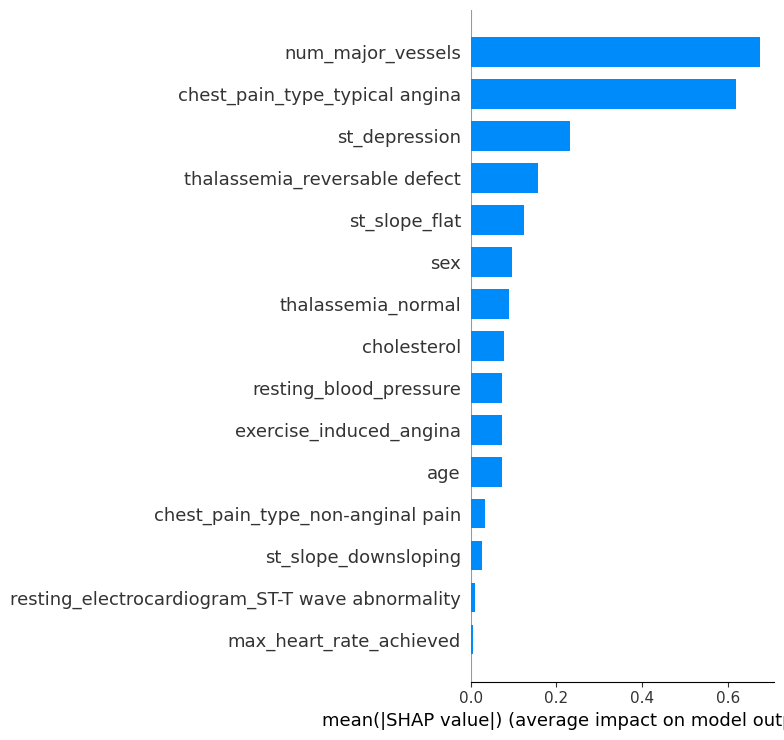

In [48]:
explainer = shap.TreeExplainer(mejor_modelo_xgb)
shap_values = explainer(X_val)

shap.summary_plot(
    shap_values,
    X_val,
    plot_type="bar",
    max_display=15
)

# Guardar el modelo

In [ ]:
#Linea para guardar el modelo entrenado en un archivo JSON
mejor_modelo_xgb.save_model("modelo_xgb_v1.json")